<a href="https://colab.research.google.com/github/NamanBansal9/UCS420/blob/main/lab_assiqnment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024170407          # <-- your full roll number
NAME = "Naman Bansal"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170407   Name: Naman Bansal   Fingerprint: D9479563   Tickets: 14

Ticket_ID                                                                                          Ticket_Text
      T01                                                                I need Windows 11 by 5.30 p.m. today.
      T02               I was locked out of the Matlab while uploading the file. It works on another computer.
      T03                               The student portal keeps asking for login. I have tried several times!
      T04                                The student portal keeps asking for login. I don't know what changed.
      T05              Matlab stopped responding before the assignment deadline. It works on another computer.
      T06                   Python keeps asking for login after the latest update. I have tried several times!
      T07                                      Printer was working yesterday on my laptop. Can you check this?
      T08                   

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
# Your code

processed = {}

rows = []

for _, row in df.iterrows():
    ticket_id = row["Ticket_ID"]
    result = process_ticket(row["Ticket_Text"])
    processed[ticket_id] = result

    rows.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation Tokens": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique Tokens": len(set(result["tokens"])),
        "Final Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(rows)

total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation Tokens": q1_table["Punctuation Tokens"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique Tokens": q1_table["Unique Tokens"].sum(),
    "Final Tokens": q1_table["Final Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

display(q1_table)

,Ticket_ID,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,1,9,1,2,9,6
1,T02,2,18,2,9,16,7
2,T03,2,14,2,4,14,8
3,T04,2,15,2,5,14,8
4,T05,2,14,2,4,13,8
5,T06,2,16,2,5,16,9
6,T07,2,13,2,6,13,5
7,T08,2,15,2,5,15,8
8,T09,1,11,1,4,9,6
9,T10,2,12,2,4,11,6


In [6]:
# Display the first focus ticket
selected_id = FOCUS[0]

selected_text = df.loc[
    df["Ticket_ID"] == selected_id, "Ticket_Text"
].iloc[0]

selected_result = processed[selected_id]

print("Selected Ticket:", selected_id)
print("Ticket Text:", selected_text)

print("\nActual Tokens:")
print(selected_result["tokens"])

print("\nPunctuation Tokens:")
print(selected_result["punct"])

print("\nStopwords:")
print(selected_result["stops"])

print("\nFinal Tokens:")
print(selected_result["final"])

Selected Ticket: T05
Ticket Text: Matlab stopped responding before the assignment deadline. It works on another computer.

Actual Tokens:
['matlab', 'stopped', 'responding', 'before', 'the', 'assignment', 'deadline', '.', 'it', 'works', 'on', 'another', 'computer', '.']

Punctuation Tokens:
['.', '.']

Stopwords:
['before', 'the', 'it', 'on']

Final Tokens:
['matlab', 'stopped', 'responding', 'assignment', 'deadline', 'works', 'another', 'computer']


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [8]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Your code


import re

sentence_initial_capitals = []

for text in df["Ticket_Text"]:
    sentences = re.split(r"(?<=[.!?])\s+", text)

    for sentence in sentences:
        match = re.search(r"^\s*([A-Z][A-Za-z]*)\b", sentence)

        if match:
            sentence_initial_capitals.append(match.group(1))

print(
    "Capitalized words found at the beginning of sentences:"
)

print(sentence_initial_capitals)
print("Count:", len(sentence_initial_capitals))

Capitalized words found at the beginning of sentences:
['I', 'I', 'It', 'The', 'I', 'The', 'I', 'Matlab', 'It', 'Python', 'I', 'Printer', 'Can', 'Password', 'Is', 'I', 'Student', 'Please', 'I', 'Email', 'I', 'I', 'I', 'I']
Count: 24


**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [9]:
# Your code

from nltk.tokenize import RegexpTokenizer, word_tokenize

CUSTOM_PATTERN = r"""
https?://[^\s]+
|www\.[^\s]+
|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}
|(?:\+\d{1,3}[- ]?)?\d{3,5}(?:[- ]\d{2,5}){1,2}
|\d+(?:\.\d+)+
|[A-Za-z]+(?:-[A-Za-z]+)+
|[A-Za-z]+(?:'[A-Za-z]+)+
|[A-Za-z]+
|\d+
"""

my_tokenizer = RegexpTokenizer(CUSTOM_PATTERN, flags=re.VERBOSE)


def my_tokenize(text):
    return my_tokenizer.tokenize(text)

print("========== CUSTOM TOKENIZER ON TEST_LINES ==========")

for i, line in enumerate(TEST_LINES, start=1):

    print(f"\nTEST LINE {i}")
    print("Original:")
    print(line)

    print("\nmy_tokenize():")
    print(my_tokenize(line))

    print("\nword_tokenize():")
    print(word_tokenize(line))

different_tickets = []

for _, row in df.iterrows():

    ticket_id = row["Ticket_ID"]
    text = row["Ticket_Text"]

    custom_tokens = my_tokenize(text)
    nltk_tokens = word_tokenize(text)

    if custom_tokens != nltk_tokens:
        different_tickets.append(ticket_id)

print("\n\nTickets tokenized differently:")
print(different_tickets)

print("Number of different tickets:", len(different_tickets))
print("Total tickets:", len(df))

========== CUSTOM TOKENIZER ON TEST_LINES ==========

TEST LINE 1
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

my_tokenize():
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

word_tokenize():
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

TEST LINE 2
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

my_tokenize():
['Call', '+91 98765 43210', '+91-98765-43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1', '250']

word_tokenize():
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

TEST LINE 3
Original

In [10]:
print("\n========== TOKENIZATION DIFFERENCES ==========")

shown = 0

for _, row in df.iterrows():

    ticket_id = row["Ticket_ID"]
    text = row["Ticket_Text"]

    custom = my_tokenize(text)
    nltk = word_tokenize(text)

    if custom != nltk:

        print("\nTicket:", ticket_id)
        print("Text:", text)

        print("\nmy_tokenize():")
        print(custom)

        print("\nword_tokenize():")
        print(nltk)

        shown += 1

        if shown == 5:
            break


========== TOKENIZATION DIFFERENCES ==========

Ticket: T01
Text: I need Windows 11 by 5.30 p.m. today.

my_tokenize():
['I', 'need', 'Windows', '11', 'by', '5.30', 'p', 'm', 'today']

word_tokenize():
['I', 'need', 'Windows', '11', 'by', '5.30', 'p.m.', 'today', '.']

Ticket: T02
Text: I was locked out of the Matlab while uploading the file. It works on another computer.

my_tokenize():
['I', 'was', 'locked', 'out', 'of', 'the', 'Matlab', 'while', 'uploading', 'the', 'file', 'It', 'works', 'on', 'another', 'computer']

word_tokenize():
['I', 'was', 'locked', 'out', 'of', 'the', 'Matlab', 'while', 'uploading', 'the', 'file', '.', 'It', 'works', 'on', 'another', 'computer', '.']

Ticket: T03
Text: The student portal keeps asking for login. I have tried several times!

my_tokenize():
['The', 'student', 'portal', 'keeps', 'asking', 'for', 'login', 'I', 'have', 'tried', 'several', 'times']

word_tokenize():
['The', 'student', 'portal', 'keeps', 'asking', 'for', 'login', '.', 'I', 'have', 

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [11]:
# Your code

from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

unique_final_tokens = sorted(
    set(
        token
        for result in processed.values()
        for token in result["final"]
    )
)

print("Number of unique final tokens:", len(unique_final_tokens))

for suffix in ["ing", "ed", "ly", "s"]:
    examples = [
        word for word in unique_final_tokens
        if word.endswith(suffix) and len(word) > len(suffix) + 2
    ]

    print(f"\nWords ending in '{suffix}':")
    print(examples[:20])


regexp_stemmer = RegexpStemmer(r"ing$", min=5)

def wordnet_pos(treebank_tag):

    if treebank_tag.startswith("J"):
        return "a"
    elif treebank_tag.startswith("V"):
        return "v"
    elif treebank_tag.startswith("N"):
        return "n"
    elif treebank_tag.startswith("R"):
        return "r"
    else:
        return "n"

tagged_words = pos_tag(unique_final_tokens)

comparison = []

for word, tag in tagged_words:

    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp_stemmer.stem(word)

    wn_pos = wordnet_pos(tag)
    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    comparison.append({
        "Word": word,
        "POS": tag,
        "Porter": porter_result,
        "Lancaster": lancaster_result,
        "Regexp": regexp_result,
        "WordNet Lemma": lemma_result
    })


stem_table = pd.DataFrame(comparison)

different_table = stem_table[
    (stem_table["Porter"] != stem_table["Lancaster"]) |
    (stem_table["Porter"] != stem_table["Regexp"]) |
    (stem_table["Porter"] != stem_table["WordNet Lemma"]) |
    (stem_table["Lancaster"] != stem_table["Regexp"]) |
    (stem_table["Lancaster"] != stem_table["WordNet Lemma"]) |
    (stem_table["Regexp"] != stem_table["WordNet Lemma"])
].reset_index(drop=True)


print("\n========== WORDS WITH DIFFERENT OUTPUTS ==========")

display(different_table)


Number of unique final tokens: 60

Words ending in 'ing':
['anything', 'asking', 'getting', 'responding', 'syncing', 'uploading', 'working']

Words ending in 'ed':
['changed', 'connected', 'locked', 'logged', 'stopped', 'tried']

Words ending in 'ly':
[]

Words ending in 's':
['campus', 'keeps', 'times', 'windows', 'works']

========== WORDS WITH DIFFERENT OUTPUTS ==========


,Word,POS,Porter,Lancaster,Regexp,WordNet Lemma
0,another,DT,anoth,anoth,another,another
1,anything,NN,anyth,anyth,anyth,anything
2,assignment,NN,assign,assign,assignment,assignment
3,campus,VB,campu,camp,campus,campus
4,change,NN,chang,chang,change,change
5,changed,VBD,chang,chang,changed,change
6,computer,NN,comput,comput,computer,computer
7,connected,VBD,connect,connect,connected,connect
8,deadline,JJ,deadlin,deadlin,deadline,deadline
9,file,NN,file,fil,file,file


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

========== CORPUS STATISTICS ==========


,Corpus,Total Tokens,Unique Tokens,TTR
0,S1,195,98,0.502564
1,S2,167,93,0.556886
2,S3,97,60,0.618557
3,S4,97,57,0.587629



========== TOP 10 WORDS OF S1 ==========
.: 18
i: 13
the: 9
!: 6
student: 4
portal: 4
login: 4
tried: 4
n't: 4
on: 3

========== TOP 10 WORDS OF S3 ==========
student: 4
portal: 4
login: 4
tried: 4
n't: 4
another: 3
keeps: 3
asking: 3
several: 3
times: 3


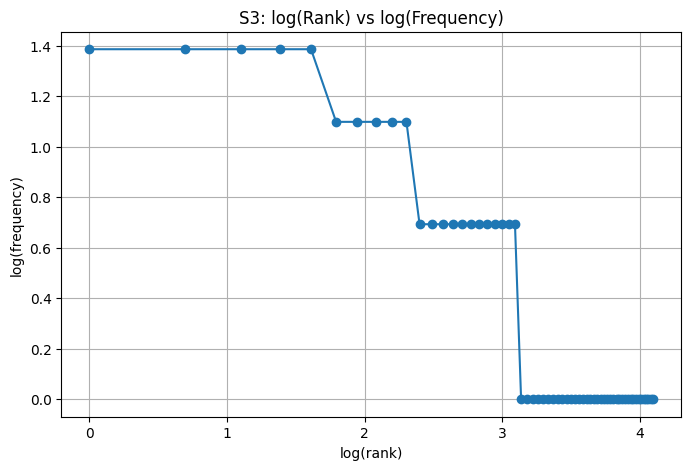


========== TOP 5 BIGRAMS OF S1 ==========
('.', 'i'): 8
('student', 'portal'): 4
('the', 'student'): 3
('keeps', 'asking'): 3
('asking', 'for'): 3

========== TOP 5 BIGRAMS OF S3 ==========
('student', 'portal'): 4
('keeps', 'asking'): 3
('asking', 'login'): 3
('tried', 'several'): 3
('several', 'times'): 3


In [12]:
# Your code

from collections import Counter
from nltk.util import bigrams
import numpy as np
import matplotlib.pyplot as plt

S1 = [
    token
    for result in processed.values()
    for token in result["tokens"]
]

S2 = [
    token
    for result in processed.values()
    for token in result["tokens"]
    if not is_punct(token)
]

S3 = [
    token
    for result in processed.values()
    for token in result["final"]
]

S4 = [porter.stem(token) for token in S3]

def corpus_statistics(tokens):

    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total > 0 else 0

    return total, unique, ttr


statistics = []

for name, corpus in [
    ("S1", S1),
    ("S2", S2),
    ("S3", S3),
    ("S4", S4)
]:

    total, unique, ttr = corpus_statistics(corpus)

    statistics.append({
        "Corpus": name,
        "Total Tokens": total,
        "Unique Tokens": unique,
        "TTR": ttr
    })


stats_table = pd.DataFrame(statistics)

print("========== CORPUS STATISTICS ==========")
display(stats_table)

s1_frequency = Counter(S1)
s3_frequency = Counter(S3)

print("\n========== TOP 10 WORDS OF S1 ==========")

for word, frequency in s1_frequency.most_common(10):
    print(f"{word}: {frequency}")


print("\n========== TOP 10 WORDS OF S3 ==========")

for word, frequency in s3_frequency.most_common(10):
    print(f"{word}: {frequency}")

ranked_frequencies = sorted(
    s3_frequency.values(),
    reverse=True
)

ranks = np.arange(1, len(ranked_frequencies) + 1)
frequencies = np.array(ranked_frequencies)

plt.figure(figsize=(8, 5))

plt.plot(
    np.log(ranks),
    np.log(frequencies),
    marker="o",
    linestyle="-"
)

plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("S3: log(Rank) vs log(Frequency)")
plt.grid(True)
plt.show()

s1_bigrams = Counter(bigrams(S1))
s3_bigrams = Counter(bigrams(S3))

print("\n========== TOP 5 BIGRAMS OF S1 ==========")

for pair, frequency in s1_bigrams.most_common(5):
    print(f"{pair}: {frequency}")


print("\n========== TOP 5 BIGRAMS OF S3 ==========")

for pair, frequency in s3_bigrams.most_common(5):
    print(f"{pair}: {frequency}")

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*

**6.** Interpretation Answer briefly:

**(a)** Why does TTR change from S1 to S4 in your dataset?

**(b)** Give one example where word_tokenize() and your tokenizer differ. Explain the difference.

**(c)** Give one example where stemming produces an undesirable result.

**(d)** Give one example where POS-aware lemmatization preserves meaning better than stemming.

**(a)** TTR changes because preprocessing and stemming change both the total number
of tokens and the number of unique tokens. S1 contains punctuation,
stopwords and different word forms. S4 removes stopwords and punctuation
and then applies Porter stemming, causing related words to be mapped to
common stems. Therefore the vocabulary becomes more compact relative to
the total number of tokens, changing the TTR.

**(b)** For example, "isn't" is treated differently. word_tokenize() separates
the contraction into "is" and "n't", whereas my_tokenize() preserves
"isn't" as one token. The custom tokenizer deliberately uses a regular
expression alternative for contractions.

**(c)** An undesirable stemming result can occur when a stemmer removes too much
of a word. For example, Lancaster stemming is more aggressive than Porter
and may reduce a valid word to a shortened form that is not itself an
English word. This is an example of over-stemming.

**(d)** POS-aware lemmatization can preserve meaning better because it uses the
grammatical role of a word. For example, "was" can be lemmatized as
"be" when it is tagged as a verb. A stemmer does not understand this
grammatical meaning; it only applies suffix-removal rules. Therefore
WordNet lemmatization with POS information can produce a meaningful
dictionary form instead of an artificial stem.